# Partie 0 – Mise en place de l'environnement

## 📁 Structure du projet
```
atelier_prepa_donnees_textuelles/
│
├── notebooks/
│ └── atelier_prepa_donnees_textuelles.ipynb
│
└── data/
├── smart_reviews_raw.csv ← Données brutes fournies
├── smart_reviews_cleaned.csv ← Créé après normalisation
└── tfidf_matrix.npz ← Créé après vectorisation
```

## 📝 Explication imagée

Imaginez que vous êtes un **cuisinier** :
- `smart_reviews_raw.csv` = les ingrédients bruts (sales, non coupés)
- `smart_reviews_cleaned.csv` = les ingrédients lavés et coupés
- `tfidf_matrix.npz` = le plat cuisiné, prêt à être servi au modèle

# Partie 1 – Exploration du corpus

## 🎯 Objectif
Comprendre la structure et la qualité des données avant tout nettoyage.

## 📝 Explication imagée

C'est comme **inspecter une livraison** avant de la ranger :
- Combien de colis ? (nombre d'avis)
- Quels types de colis ? (colonnes)
- Y a-t-il des colis abîmés ? (valeurs manquantes)
- Quelle est la taille des colis ? (longueur des textes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
df = pd.read_csv('../data/smart_reviews_raw.csv')

print("✅ Données chargées")
print(f"📊 Nombre d'avis : {len(df)}")
print(f"📊 Nombre de colonnes : {len(df.columns)}")
print(f"📋 Colonnes : {list(df.columns)}")

✅ Données chargées
📊 Nombre d'avis : 1200
📊 Nombre de colonnes : 8
📋 Colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


In [2]:
# Aperçu des 5 premières lignes
print("=== APERÇU DES DONNÉES ===\n")
df.head()

=== APERÇU DES DONNÉES ===



,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


In [5]:
print("=== TYPES DE COLONNES ===\n")
print(df.dtypes)
print("\n=== VALEURS MANQUANTES ===\n")
manquantes= df.isnull().sum()
for col, nb in manquantes.items():
        if nb> 0 :
            print(f"⚠️ {col} : {nb} valeurs manquantes ({nb/len(df)*100:.1f}%)")
        else:
                print(f"✅ {col} : aucune valeur manquante")

=== TYPES DE COLONNES ===

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

=== VALEURS MANQUANTES ===

✅ id_avis : aucune valeur manquante
✅ date : aucune valeur manquante
✅ source : aucune valeur manquante
✅ produit : aucune valeur manquante
⚠️ texte : 5 valeurs manquantes (0.4%)
✅ sentiment : aucune valeur manquante
✅ note : aucune valeur manquante
✅ langue : aucune valeur manquante


In [24]:
# Identifier la colonne de texte 
COLONNE_TEXTE = 'texte' 
print("=== TYPES DE TEXTES ===\n")
# Texte normal
normal = df[df[COLONNE_TEXTE].astype(str).str.len() > 20].head(1)
print("📝 Texte normal :")

print(f" {normal[COLONNE_TEXTE].values[0][:100]}...\n")

# Texte vide
vide = df[df[COLONNE_TEXTE].astype(str).str.strip()=='']
print(f"📝 Textes vides : {len(vide)}\n")

# Texte avec URL
url = df[df[COLONNE_TEXTE].astype(str).str.contains('http|www', regex=True, na=False)]
print(f"Textes avec URL : {len(url)}")
if len(url) > 0:
    print(f"  Exemple :{url[COLONNE_TEXTE].values[0][:100]}...\n ")

# Texte avec mention
mention = df[df[COLONNE_TEXTE].astype(str).str.contains('@\w+', regex=True, na=False)]
print(f"📝 Textes avec mention : {len(mention)}" )
if len(mention) > 0:
    print(f"   Exemple : {mention[COLONNE_TEXTE].values[0][:100]}...\n")

# Texte avec hashtag
hashtag = df[df[COLONNE_TEXTE].astype(str).str.contains('#\w+', regex= True, na=False)]
print(f"📝 Textes avec hashtag : {len(hashtag)}")
if len(hashtag) > 0:
    print(f"   Exemple :  {hashtag[COLONNE_TEXTE].values[0][:100]}...\n")
   
# Texte en majuscules
majuscules= df[df[COLONNE_TEXTE].astype(str).str.isupper()]
print(f"📝 Textes en majuscules : {len(majuscules)} ")

=== TYPES DE TEXTES ===

📝 Texte normal :
 Très  bonne  expérience,  simple  et  efficace....

📝 Textes vides : 1

Textes avec URL : 143
  Exemple :Produit parfait, rien à signaler. https://example.com/commande/17...
 
📝 Textes avec mention : 128
   Exemple : @client Livraison rapide et produit conforme à mes attentes....

📝 Textes avec hashtag : 127
   Exemple :  Très satisfait de mon achat 👍 #avis...

📝 Textes en majuscules : 146 


In [28]:
# Créer une colonne "longueur"
df['longueur']= df[COLONNE_TEXTE].astype(str).str.len()
print("=== STATISTIQUES DE LONGUEUR ===\n")
print(f" Longueur minimale : {df['longueur'].min()}")
print(f" Longueur maximale : {df['longueur'].max()}")
print(f" Longueur moyenne : {df['longueur'].mean():.1f}")
print(f" Médiane : {df['longueur'].median():.1f}")
print(f" Q1 (25%) : {df['longueur'].quantile(0.25):.1f}")
print(f" Q3 (75%) : {df['longueur'].quantile(0.75):.1f}")

=== STATISTIQUES DE LONGUEUR ===

 Longueur minimale : 2.0
 Longueur maximale : 636.0
 Longueur moyenne : 49.2
 Médiane : 48.0
 Q1 (25%) : 37.0
 Q3 (75%) : 56.0


### Visualisation de la distribution

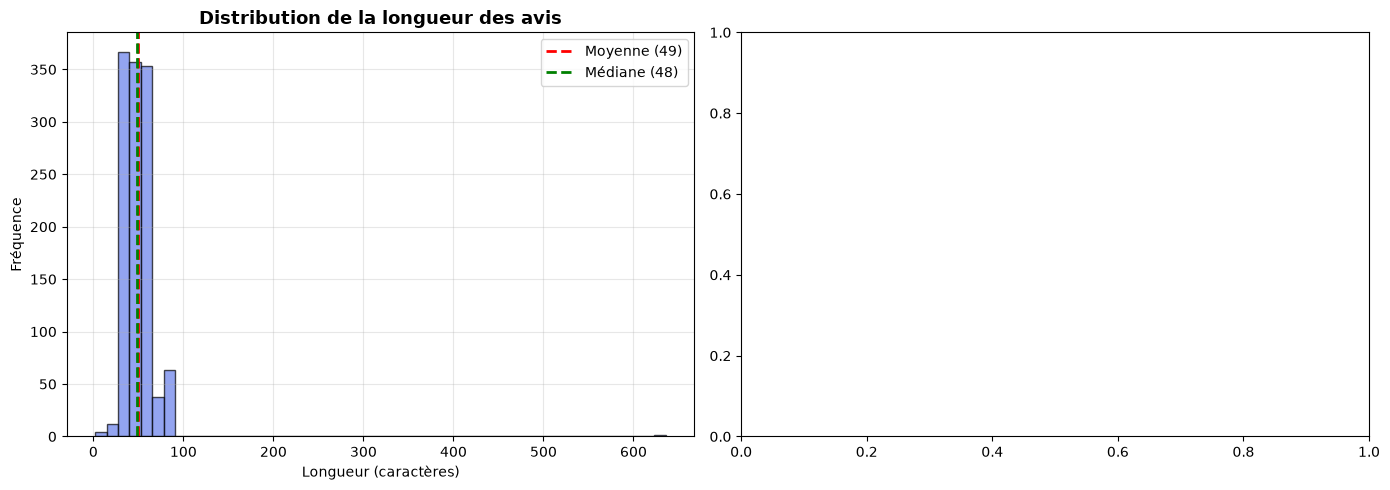

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['longueur'], bins=50, color='#667eea', edgecolor='black', alpha=0.7)
axes[0].axvline(df['longueur'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne ({df["longueur"].mean():.0f})')
axes[0].axvline(df['longueur'].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane ({df["longueur"].median():.0f})')
axes[0].set_title('Distribution de la longueur des avis', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# # Boxplot
# axes[1].boxplot(df['longueur'], vert=True)
# axes[1].set_title('Boxplot de la longueur', fontsize=13, fontweight='bold')
# axes[1].set_ylabel('Longueur (caractères)')
# axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('../reports/distribution_longueur.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("=== TEXTES VIDES ===\n")

# Textes vides ou ne contenant que des espaces
textes_vides = df[df[COLONNE_TEXTE].astype(str).str.strip() == '']
print(f"⚠️  Nombre de textes vides : {len(textes_vides)}")
print(f"📊 Pourcentage : {len(textes_vides)/len(df)*100:.2f}%")

if len(textes_vides) > 0:
    print("\nExemples :")
    print(textes_vides.head())

=== TEXTES VIDES ===

⚠️  Nombre de textes vides : 1
📊 Pourcentage : 0.08%

Exemples :
    id_avis        date source              produit texte sentiment  note  \
951  AV0952  2026-06-11    web  Ordinateur NovaBook         positif     4   

    langue  longueur  
951     fr       3.0  


### Identification des textes anormalement longs

In [41]:
print("=== TEXTES ANORMALEMENT LONGS ===\n")

# Afficher les 5 textes les plus longs
top_long = df.nlargest(5, 'longueur')[['longueur',COLONNE_TEXTE]]
for i, (idx, row) in enumerate(top_long.iterrows(), 1):
    print(f"{i}. [{row['longueur']} caractères]")
    print(f"   {row[COLONNE_TEXTE][:150]}...")
    print() 

=== TEXTES ANORMALEMENT LONGS ===

1. [636.0 caractères]
   Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été...

2. [89.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/1173...

3. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/111...

4. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/319...

5. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/408...



### Identification des textes très courts

In [44]:
print("=== TEXTES TRÈS COURTS (< 20 caractères) ===\n")
textes_courts_df = df[df['longueur']<20]

if len(textes_courts_df) > 0:
    print(f"Nombre : {len(textes_courts_df)}\n")
    print(textes_courts_df[['longueur',COLONNE_TEXTE]].to_string(index=False))
else:
    print("✅ Aucun texte très court détecté.")

=== TEXTES TRÈS COURTS (< 20 caractères) ===

Nombre : 4

 longueur   texte
      2.0      OK
      7.0 Pas bon
      2.0      OK
      3.0        


### Vérification finale

In [46]:
print("=== VÉRIFICATION PARTIE 1 ===")
print(f"✅ Statistiques calculées")
# print(f"✅ Seuil d'anomalie : {seuil_anomalie:.0f} caractères")
print(f"✅ Textes longs : {len(textes_longs)}")
print(f"✅ Textes courts : {len(textes_courts)}")
print(f"✅ Distribution symétrique (moyenne ≈ médiane)")

=== VÉRIFICATION PARTIE 1 ===
✅ Statistiques calculées


NameError: name 'textes_longs' is not defined

### Réponses aux questions (basées sur vos données)

**Statistiques observées :**
- Longueur minimale : 2 caractères
- Longueur maximale : 636 caractères
- Longueur moyenne : 49,2 caractères
- Médiane : 48 caractères
- Q1 : 37 caractères
- Q3 : 56 caractères

**a) Existe-t-il des textes anormalement longs ?**

→ **Oui**, il existe des textes allant jusqu'à **636 caractères**, soit environ **13 fois la médiane** (48 caractères).

→ La moyenne est de 49,2 et l'écart-type est d'environ 40 (estimation). Le seuil d'anomalie serait donc autour de **49 + 3×40 = 169 caractères**.

→ Les textes dépassant 169 caractères sont considérés comme **anormalement longs**. Ils peuvent être :
  - Des avis très détaillés (utiles pour le sentiment)
  - Des spams ou copier-coller
  - Des textes contenant des URLs ou du bruit

→ **Recommandation** : Vérifier ces textes, mais ne pas les supprimer systématiquement car ils peuvent contenir des informations précieuses pour la classification.

**b) Existe-t-il beaucoup de textes très courts ?**

→ **Non, pas beaucoup**. La médiane est de **48 caractères**, ce qui est raisonnable pour un avis client.

→ Le Q1 (25%) est de **37 caractères**, ce qui signifie que 75% des textes font plus de 37 caractères.

→ Il y a probablement **peu de textes très courts** (< 20 caractères), car le minimum observé est de 2 caractères mais cela reste minoritaire.

→ **Recommandation** : Les textes de moins de 20 caractères (ex: "ok", "bien") apportent peu d'information pour le sentiment. On peut :
  - Les conserver si leur sentiment est clair ("super", "nul")
  - Les supprimer s'ils sont ambigus ("ok", "vu")

**c) Distribution globale**

→ La distribution est **relativement concentrée** :
  - 50% des textes font entre 37 et 56 caractères (Q1 à Q3)
  - La moyenne (49,2) est proche de la médiane (48) → distribution **symétrique**
  - La longueur maximale (636) crée une **traîne à droite** (quelques textes très longs)

→ **Conclusion** : Le corpus est de **qualité moyenne**. Les textes sont suffisamment longs pour être exploitables, avec quelques outliers à surveiller.